In [1]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from scipy import optimize
import sympy as sp

 - https://stackoverflow.com/questions/75849031/solving-multiple-solution-equation-in-python/79842098#79842098
 - https://www.perplexity.ai/search/how-to-count-how-many-root-the-VQiA3p93SQC1wB_fOUr_tQ
 - https://www.wolframalpha.com/input?i=solve+tan%284+*+x%29+%3D+-+3.1*sin%28x%29+%2F+%281+%2B+3.1*cos%28x%29%29+for+x
 - https://www.wolframalpha.com/input?i=solve+tan%28M+*+x%29+%3D+-+D*sin%28x%29+%2F+%281+%2B+D*cos%28x%29%29+for+x+and+M+%3E+0%2C+D+%3E+0

In [2]:
def f_naive(x, M, delta):
    return np.tan(M * x) + delta * np.sin(x) / (1. + delta * np.cos(x))

In [3]:
def f(x, M, delta):
    return np.tan(M * x) * (1. + delta * np.cos(x)) + delta * np.sin(x)

In [4]:
p0s = [
    {"M": 1., "delta": 0.5},
    {"M": 1., "delta": 1.},
    {"M": 4., "delta": 0.5},
    {"M": 1., "delta": 3.1},
    {"M": 4., "delta": 3.0},
    {"M": 4., "delta": 3.1},
]

In [5]:
ymax = 10.

In [6]:
xlin = np.linspace(- 0.1, np.pi + 0.1, 2000)

In [7]:
def g(x, M, delta):
    return np.tan(M * x)

In [8]:
def h(x, M, delta):
    return - delta * np.sin(x) / (1. +  delta * np.cos(x))

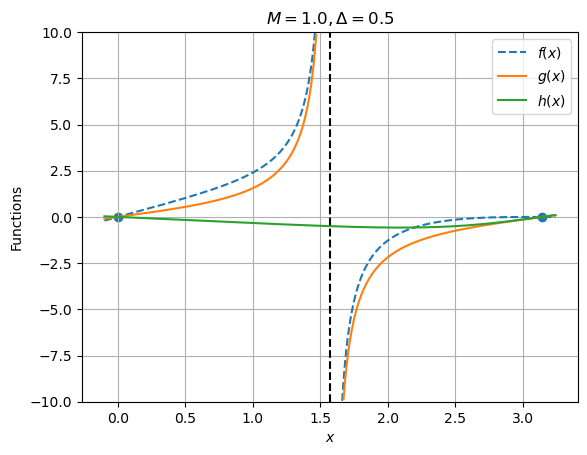

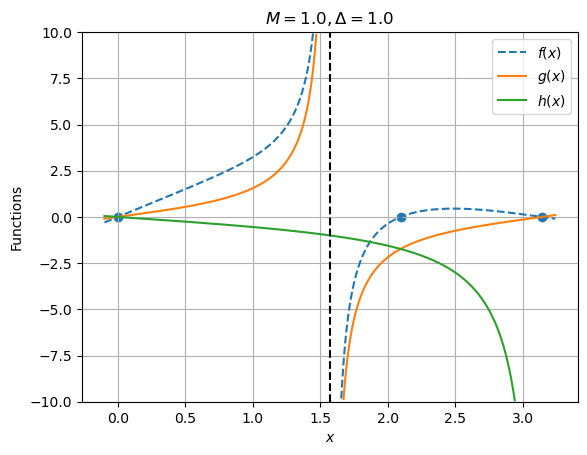

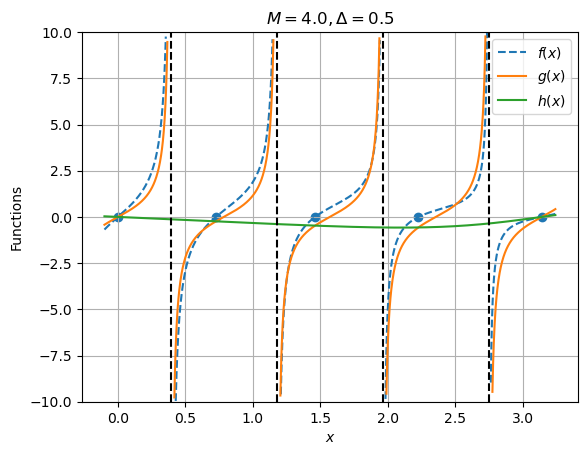

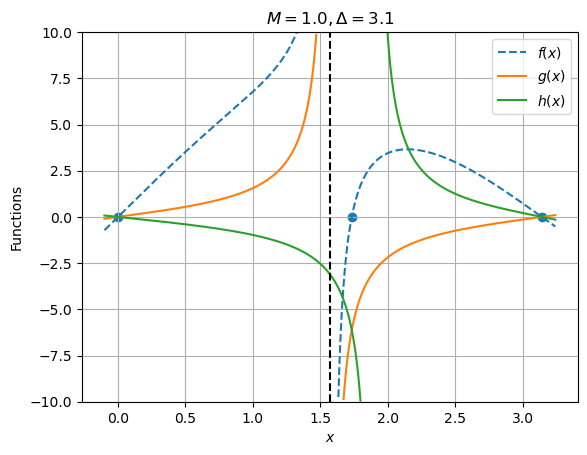

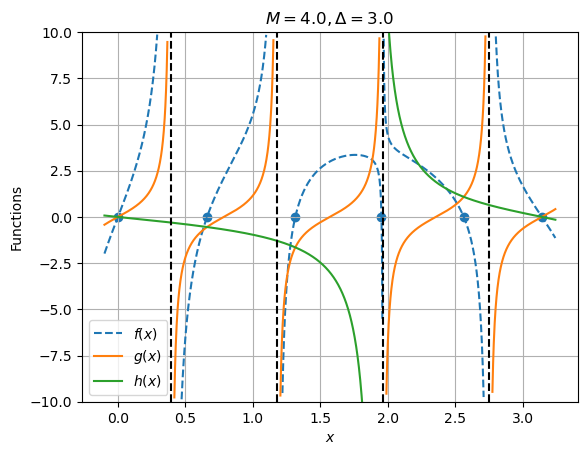

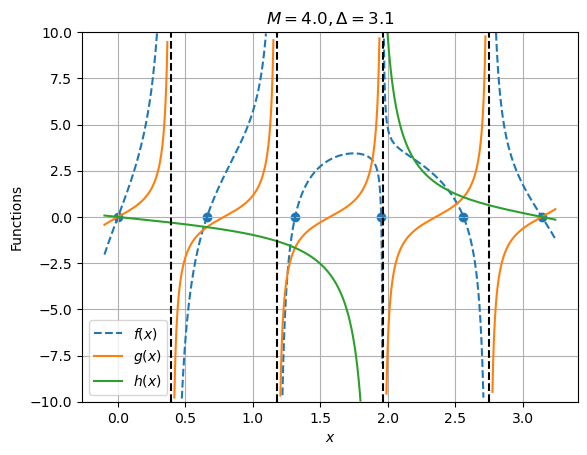

In [9]:
for p0 in p0s:
    
    flin = f(xlin, **p0)
    flin[np.abs(flin)>ymax] = np.nan

    glin = g(xlin, **p0)
    glin[np.abs(glin)>ymax] = np.nan
    
    hlin = h(xlin, **p0)
    hlin[np.abs(hlin)>ymax] = np.nan
    
    asymptotes = np.arange(-np.pi / (2 * p0['M']), np.pi, np.pi / (p0['M']))[1:]
    initial_guesses = [0.] + list(itertools.chain.from_iterable([(0.999 * x, 1.001 * x) for x in asymptotes])) + [np.pi]

    _roots = []
    for initial_guess in initial_guesses:
        root = optimize.root(f, x0=initial_guess, args=(p0['M'], p0['delta']))
        if root.success:
            _roots.append(root.x[0])

    diff = np.abs(np.diff(_roots)) < 1e-6
    roots = []
    for (query, value) in zip(diff, _roots):
        if not query:
            roots.append(value)
    roots += [_roots[-1]]
    
    fig, axe = plt.subplots()
    axe.plot(xlin, flin, "--")
    axe.plot(xlin, glin)
    axe.plot(xlin, hlin)
    axe.scatter(roots, [0.] * len(roots))
    for asymptote in asymptotes:
        axe.axvline(asymptote, color="black", linestyle="--")
        
    axe.set_ylim([-ymax, ymax])
    axe.grid()
    axe.set_title(rf"$M={p0['M']}, \Delta={p0['delta']}$")
    axe.set_xlabel("$x$")
    axe.set_ylabel("Functions")
    axe.legend(["$f(x)$", "$g(x)$", "$h(x)$"])

In [10]:
f_naive(1.95055524, 4, 3.1)

4.869340983759685e-06

In [11]:
roots

[0.0,
 0.659564741240224,
 1.312752197091748,
 1.9505552374030901,
 2.560826810291762,
 3.141592653589793]